In [313]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

In [314]:
random.seed(42)

In [315]:
# Load dataset
df = pd.read_csv('Data_consumo_Edesur_2012-2024.csv')

In [152]:
df

,Empresa Distribuidora,Tipo Cliente,Mes,Año,date,Energía (gwh),Potencia (mw)
0,EdeEste,Ayuntamiento,1,2012,2012-01-01,5.455723,17.607010
1,EdeEste,Ayuntamiento,1,2013,2013-01-01,6.269137,15.787330
2,EdeEste,Ayuntamiento,1,2014,2014-01-01,6.228713,15.865480
3,EdeEste,Ayuntamiento,1,2015,2015-01-01,7.790957,16.157110
4,EdeEste,Ayuntamiento,1,2016,2016-01-01,8.268114,16.102980
...,...,...,...,...,...,...,...
2335,EdeSur,Residencial,12,2020,2020-12-01,137.600105,31.510346
2336,EdeSur,Residencial,12,2021,2021-12-01,141.045316,35.980329
2337,EdeSur,Residencial,12,2022,2022-12-01,147.231416,57.268129
2338,EdeSur,Residencial,12,2023,2023-12-01,159.370000,59.190000


In [316]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

In [154]:
df.columns

Index(['empresa_distribuidora', 'tipo_cliente', 'mes', 'año', 'date',
       'energía_gwh', 'potencia_mw'],
      dtype='object')

In [317]:
dummies = pd.get_dummies(df, columns=['empresa_distribuidora'], prefix="", dtype=int, prefix_sep="", )
df = pd.concat([df["empresa_distribuidora"], dummies], axis=1)

In [318]:
dummies = pd.get_dummies(df, columns=['tipo_cliente'], prefix="", dtype=int, prefix_sep="")
df = pd.concat([df['tipo_cliente'], dummies], axis=1)

In [157]:
df.head()

,tipo_cliente,empresa_distribuidora,mes,año,date,energía_gwh,potencia_mw,EdeEste,EdeNorte,EdeSur,Ayuntamiento,Comercial,Gobierno,Industrial,Residencial
0,Ayuntamiento,EdeEste,1,2012,2012-01-01,5.455723,17.60701,1,0,0,1,0,0,0,0
1,Ayuntamiento,EdeEste,1,2013,2013-01-01,6.269137,15.78733,1,0,0,1,0,0,0,0
2,Ayuntamiento,EdeEste,1,2014,2014-01-01,6.228713,15.86548,1,0,0,1,0,0,0,0
3,Ayuntamiento,EdeEste,1,2015,2015-01-01,7.790957,16.15711,1,0,0,1,0,0,0,0
4,Ayuntamiento,EdeEste,1,2016,2016-01-01,8.268114,16.10298,1,0,0,1,0,0,0,0


In [319]:
df_corr = df.corr(numeric_only=True, ).applymap(lambda x: float(f"{x:.4f}"))

C:\Users\Admin\AppData\Local\Temp\ipykernel_3588\252309064.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_corr = df.corr(numeric_only=True, ).applymap(lambda x: float(f"{x:.4f}"))


In [159]:
df_corr

,mes,año,energía_gwh,potencia_mw,EdeEste,EdeNorte,EdeSur,Ayuntamiento,Comercial,Gobierno,Industrial,Residencial
mes,1.0000,0.0000,0.0613,0.0212,0.0000,-0.000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000
año,0.0000,1.0000,0.1970,0.2002,-0.0000,-0.000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000
energía_gwh,0.0613,0.1970,1.0000,0.3028,-0.1665,0.005,0.1616,-0.5024,-0.1653,-0.2739,0.1669,0.7747
potencia_mw,0.0212,0.2002,0.3028,1.0000,-0.1384,-0.110,0.2484,-0.4036,-0.1191,-0.0140,0.7745,-0.2380
EdeEste,0.0000,-0.0000,-0.1665,-0.1384,1.0000,-0.500,-0.5000,0.0000,0.0000,0.0000,-0.0000,0.0000
EdeNorte,-0.0000,-0.0000,0.0050,-0.1100,-0.5000,1.000,-0.5000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000
EdeSur,-0.0000,0.0000,0.1616,0.2484,-0.5000,-0.500,1.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000
Ayuntamiento,0.0000,-0.0000,-0.5024,-0.4036,0.0000,-0.000,-0.0000,1.0000,-0.2500,-0.2500,-0.2500,-0.2500
Comercial,0.0000,-0.0000,-0.1653,-0.1191,0.0000,-0.000,0.0000,-0.2500,1.0000,-0.2500,-0.2500,-0.2500
Gobierno,-0.0000,0.0000,-0.2739,-0.0140,0.0000,-0.000,-0.0000,-0.2500,-0.2500,1.0000,-0.2500,-0.2500


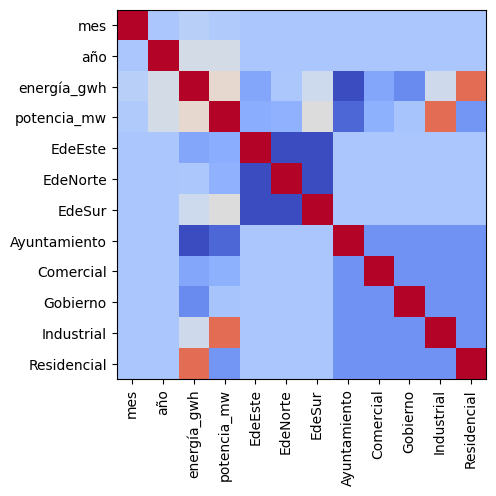

In [160]:
plt.imshow(df_corr, cmap='coolwarm', interpolation='nearest')
plt.xticks(range(len(df_corr.columns)), df_corr.columns, rotation=90, ha='center')
plt.yticks(range(len(df_corr.columns)), df_corr.columns)
plt.show()

In [161]:
# df['date'] = pd.to_datetime(df['date'])
# suponiendo cada fila ya es mes-region, pero por si hay duplicados:
agg = df.groupby(['empresa_distribuidora', 'año', 'mes']).agg(
    energia_gwh=('energía_gwh','sum'),
    potencia_mw=('potencia_mw','mean'),
).reset_index()

# Opcional: si quieres series separadas por empresa
# series_by_region = {r: g.set_index('date').asfreq('MS') for r, g in agg.groupby('empresa_distribuidora')}


In [162]:
agg

,empresa_distribuidora,año,mes,energia_gwh,potencia_mw
0,EdeEste,2012,1,134.718079,50.145008
1,EdeEste,2012,2,134.149974,50.982608
2,EdeEste,2012,3,167.726941,50.210158
3,EdeEste,2012,4,174.172468,53.075526
4,EdeEste,2012,5,185.099284,52.616166
...,...,...,...,...,...
463,EdeSur,2024,8,463.530000,148.834000
464,EdeSur,2024,9,471.168000,152.883140
465,EdeSur,2024,10,466.311953,149.351181
466,EdeSur,2024,11,452.770430,153.627738


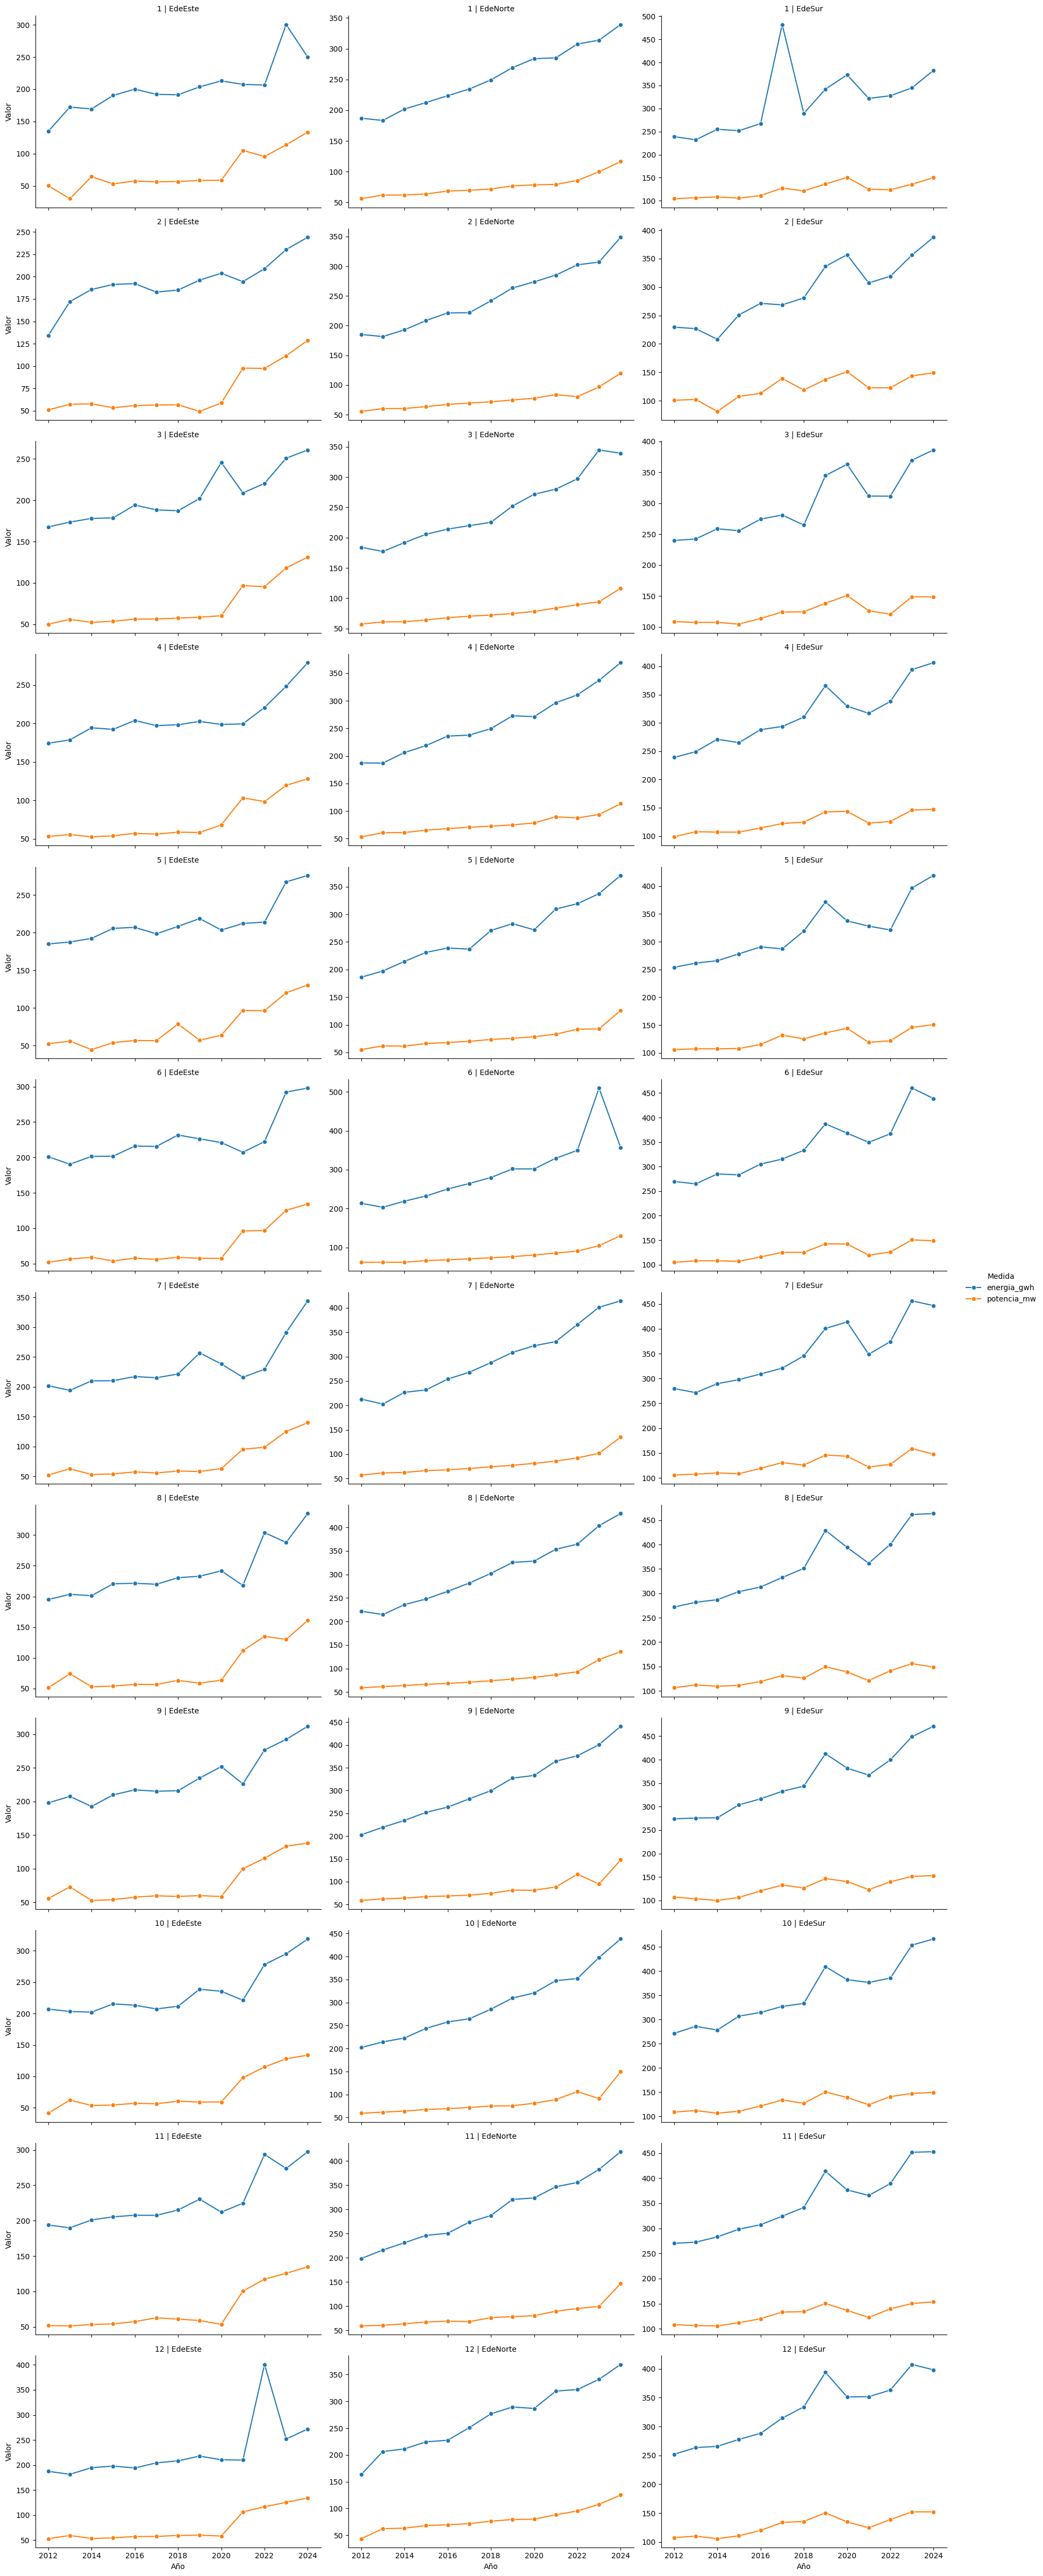

In [163]:
agg = df.groupby(['empresa_distribuidora','año', 'mes']).agg(
    energia_gwh=('energía_gwh','sum'),
    potencia_mw=('potencia_mw','mean'),
).reset_index()
# Melt the DataFrame to long format for easier plotting with seaborn
agg_melted = agg.melt(
    id_vars=["empresa_distribuidora", 'año', 'mes'],
    value_vars=["energia_gwh", "potencia_mw"],
    var_name="Medida",
    value_name="Valor"
)

# Create faceted line plots
g = sns.FacetGrid(
    agg_melted,
    col="empresa_distribuidora",
    row="mes",
    hue="Medida",
    sharey=False,
    height=4,
    aspect=1.5
    )
g.map(sns.lineplot, "año", "Valor", marker="o")
g.add_legend(title="Medida")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("Año", "Valor")
g.tight_layout()
plt.show()

In [164]:
df

,tipo_cliente,empresa_distribuidora,mes,año,date,energía_gwh,potencia_mw,EdeEste,EdeNorte,EdeSur,Ayuntamiento,Comercial,Gobierno,Industrial,Residencial
0,Ayuntamiento,EdeEste,1,2012,2012-01-01,5.455723,17.607010,1,0,0,1,0,0,0,0
1,Ayuntamiento,EdeEste,1,2013,2013-01-01,6.269137,15.787330,1,0,0,1,0,0,0,0
2,Ayuntamiento,EdeEste,1,2014,2014-01-01,6.228713,15.865480,1,0,0,1,0,0,0,0
3,Ayuntamiento,EdeEste,1,2015,2015-01-01,7.790957,16.157110,1,0,0,1,0,0,0,0
4,Ayuntamiento,EdeEste,1,2016,2016-01-01,8.268114,16.102980,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2335,Residencial,EdeSur,12,2020,2020-12-01,137.600105,31.510346,0,0,1,0,0,0,0,1
2336,Residencial,EdeSur,12,2021,2021-12-01,141.045316,35.980329,0,0,1,0,0,0,0,1
2337,Residencial,EdeSur,12,2022,2022-12-01,147.231416,57.268129,0,0,1,0,0,0,0,1
2338,Residencial,EdeSur,12,2023,2023-12-01,159.370000,59.190000,0,0,1,0,0,0,0,1


In [320]:
df['time_idx'] = pd.DataFrame((df['año'] - df['año'].min()) * 12 + df['mes'])


In [321]:
df

,tipo_cliente,empresa_distribuidora,mes,año,date,energía_gwh,potencia_mw,EdeEste,EdeNorte,EdeSur,Ayuntamiento,Comercial,Gobierno,Industrial,Residencial,time_idx
0,Ayuntamiento,EdeEste,1,2012,2012-01-01,5.455723,17.607010,1,0,0,1,0,0,0,0,1
1,Ayuntamiento,EdeEste,1,2013,2013-01-01,6.269137,15.787330,1,0,0,1,0,0,0,0,13
2,Ayuntamiento,EdeEste,1,2014,2014-01-01,6.228713,15.865480,1,0,0,1,0,0,0,0,25
3,Ayuntamiento,EdeEste,1,2015,2015-01-01,7.790957,16.157110,1,0,0,1,0,0,0,0,37
4,Ayuntamiento,EdeEste,1,2016,2016-01-01,8.268114,16.102980,1,0,0,1,0,0,0,0,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2335,Residencial,EdeSur,12,2020,2020-12-01,137.600105,31.510346,0,0,1,0,0,0,0,1,108
2336,Residencial,EdeSur,12,2021,2021-12-01,141.045316,35.980329,0,0,1,0,0,0,0,1,120
2337,Residencial,EdeSur,12,2022,2022-12-01,147.231416,57.268129,0,0,1,0,0,0,0,1,132
2338,Residencial,EdeSur,12,2023,2023-12-01,159.370000,59.190000,0,0,1,0,0,0,0,1,144


In [170]:
df.corr(numeric_only=True).applymap(lambda x: float(f"{x:.4f}"))

C:\Users\Admin\AppData\Local\Temp\ipykernel_3588\3109774375.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.corr(numeric_only=True).applymap(lambda x: float(f"{x:.4f}"))


,mes,año,energía_gwh,potencia_mw,EdeEste,EdeNorte,EdeSur,Ayuntamiento,Comercial,Gobierno,Industrial,Residencial,time_idx
mes,1.0000,0.0000,0.0613,0.0212,0.0000,-0.000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0767
año,0.0000,1.0000,0.1970,0.2002,-0.0000,-0.000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.9971
energía_gwh,0.0613,0.1970,1.0000,0.3028,-0.1665,0.005,0.1616,-0.5024,-0.1653,-0.2739,0.1669,0.7747,0.2012
potencia_mw,0.0212,0.2002,0.3028,1.0000,-0.1384,-0.110,0.2484,-0.4036,-0.1191,-0.0140,0.7745,-0.2380,0.2012
EdeEste,0.0000,-0.0000,-0.1665,-0.1384,1.0000,-0.500,-0.5000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000
EdeNorte,-0.0000,-0.0000,0.0050,-0.1100,-0.5000,1.000,-0.5000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000
EdeSur,-0.0000,0.0000,0.1616,0.2484,-0.5000,-0.500,1.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000
Ayuntamiento,0.0000,-0.0000,-0.5024,-0.4036,0.0000,-0.000,-0.0000,1.0000,-0.2500,-0.2500,-0.2500,-0.2500,-0.0000
Comercial,0.0000,-0.0000,-0.1653,-0.1191,0.0000,-0.000,0.0000,-0.2500,1.0000,-0.2500,-0.2500,-0.2500,0.0000
Gobierno,-0.0000,0.0000,-0.2739,-0.0140,0.0000,-0.000,-0.0000,-0.2500,-0.2500,1.0000,-0.2500,-0.2500,0.0000


In [322]:
df_energia = df.groupby(['empresa_distribuidora','año', 'mes']).agg(
    energia_gwh=('energía_gwh','sum'),
    potencia_mw=('potencia_mw','mean'),
).reset_index()

In [323]:
df_energia['time_idx'] = pd.DataFrame((df_energia['año'] - df_energia['año'].min()) * 12 + df_energia['mes'])

In [324]:
df_energia["mes pasado"] = df_energia.groupby('empresa_distribuidora')['energia_gwh'].shift(1)

In [325]:
df_energia

,empresa_distribuidora,año,mes,energia_gwh,potencia_mw,time_idx,mes pasado
0,EdeEste,2012,1,134.718079,50.145008,1,NaN
1,EdeEste,2012,2,134.149974,50.982608,2,134.718079
2,EdeEste,2012,3,167.726941,50.210158,3,134.149974
3,EdeEste,2012,4,174.172468,53.075526,4,167.726941
4,EdeEste,2012,5,185.099284,52.616166,5,174.172468
...,...,...,...,...,...,...,...
463,EdeSur,2024,8,463.530000,148.834000,152,446.580000
464,EdeSur,2024,9,471.168000,152.883140,153,463.530000
465,EdeSur,2024,10,466.311953,149.351181,154,471.168000
466,EdeSur,2024,11,452.770430,153.627738,155,466.311953


In [326]:
df_energia['mes pasado'].fillna(value=df_energia['mes pasado'].min(), inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_3588\3147355620.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_energia['mes pasado'].fillna(value=df_energia['mes pasado'].min(), inplace=True)


In [327]:
df_energia.rename(columns={'mes pasado': 'mes_pasado'}, inplace=True)

In [328]:
df_energia = pd.get_dummies(df_energia, columns=['empresa_distribuidora'], prefix="", dtype=int, prefix_sep="")

In [329]:
df_energia.rename(columns={"EdeEste":'este', "EdeSur":'sur', "EdeNorte":'norte'}, inplace=True)

In [330]:
df_energia

,año,mes,energia_gwh,potencia_mw,time_idx,mes_pasado,este,norte,sur
0,2012,1,134.718079,50.145008,1,134.149974,1,0,0
1,2012,2,134.149974,50.982608,2,134.718079,1,0,0
2,2012,3,167.726941,50.210158,3,134.149974,1,0,0
3,2012,4,174.172468,53.075526,4,167.726941,1,0,0
4,2012,5,185.099284,52.616166,5,174.172468,1,0,0
...,...,...,...,...,...,...,...,...,...
463,2024,8,463.530000,148.834000,152,446.580000,0,0,1
464,2024,9,471.168000,152.883140,153,463.530000,0,0,1
465,2024,10,466.311953,149.351181,154,471.168000,0,0,1
466,2024,11,452.770430,153.627738,155,466.311953,0,0,1


In [331]:
df_energia.to_csv("data_preparada_energia.csv", index=False)

In [277]:
pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB 162.5 kB/s eta 0:07:23
   ---------------------------------------- 0.0/72.0 MB 186.2 kB/s eta 0:06:27
   ---------------------------------------- 0.1/72.0 MB 290.5 kB/s eta 0:04:08
   ---------------------------------------- 0.1/72.0 MB 297.7 kB/s eta 0:04:02
   ---------------------------------------- 0.1/72.0 MB 297.7 kB/s eta 0:04:02
   ---------------------------------------- 0.1/72.0 MB 297.7 kB/s eta 0:04:02
   ---------------------------------------- 0.1/72.0 MB 297.7 kB/s eta 0:04:02
   ---------------------------------------- 0.1/72.0 MB 327.4 kB/s eta 0:03:40
   ---------------------------------------- 0.1/72.0 MB 327.4 kB/s eta 0:03:40
   ---------------------------------------- 0.2/72.0 MB 327.3 kB/s eta 0:03:40
   ---------------------------------------- 0.2/72.0 MB 327.3 kB/s eta


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

In [332]:
# 1. Carga y preprocesamiento

df = pd.read_csv("data_preparada_energia.csv")

features = ["mes", "time_idx", "mes_pasado", "este", "norte", "sur"]
target = "energia_gwh"

X = df[features]
y = df[target]


num_cols = ["mes", "time_idx", "mes_pasado"]



In [333]:
df

,año,mes,energia_gwh,potencia_mw,time_idx,mes_pasado,este,norte,sur
0,2012,1,134.718079,50.145008,1,134.149974,1,0,0
1,2012,2,134.149974,50.982608,2,134.718079,1,0,0
2,2012,3,167.726941,50.210158,3,134.149974,1,0,0
3,2012,4,174.172468,53.075526,4,167.726941,1,0,0
4,2012,5,185.099284,52.616166,5,174.172468,1,0,0
...,...,...,...,...,...,...,...,...,...
463,2024,8,463.530000,148.834000,152,446.580000,0,0,1
464,2024,9,471.168000,152.883140,153,463.530000,0,0,1
465,2024,10,466.311953,149.351181,154,471.168000,0,0,1
466,2024,11,452.770430,153.627738,155,466.311953,0,0,1


In [334]:
preprocess = ColumnTransformer([
    ("scaler", StandardScaler(), num_cols)
], remainder="passthrough")

In [335]:
# 2. Modelos

modelos = {
    "ridge": Ridge(alpha=1.0),
    "random_forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "xgboost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

In [336]:
# 3. División train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)

In [337]:
y_train

0      134.718079
1      134.149974
2      167.726941
3      174.172468
4      185.099284
          ...    
369    314.389276
370    307.333415
371    288.250000
372    482.178130
373    268.691517
Name: energia_gwh, Length: 374, dtype: float64

In [338]:
pipelines = {}
resultados = {}

for nombre, modelo in modelos.items():

    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", TransformedTargetRegressor(
            regressor=modelo,
            transformer=StandardScaler()
        ))
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)

    pipelines[nombre] = pipe
    resultados[nombre] = {"MAE": mae, "RMSE": rmse}

for m, r in resultados.items():
    print(f"Modelo: {m} | MAE={r['MAE']:.4f} | RMSE={r['RMSE']:.4f}")


Modelo: ridge | MAE=16.4351 | RMSE=429.9139
Modelo: random_forest | MAE=38.4760 | RMSE=2057.4476
Modelo: xgboost | MAE=43.1667 | RMSE=2655.6814


In [304]:
y_train

0      0.001513
1      0.000000
2      0.089407
3      0.106570
4      0.135666
         ...   
369    0.479934
370    0.461146
371    0.410332
372    0.926716
373    0.358252
Name: energia_gwh, Length: 374, dtype: float64

In [339]:
# 5. Predecir con datos crudos

def predecir(modelo_pipe, año, mes, mes_pasado, region):
 

    base_year = df["año"].min()
    time_idx = (año - base_year) * 12 + mes

    # One-hot manual de región
    regio = {
        "este": [1, 0, 0],
        "norte": [0, 1, 0],
        "sur": [0, 0, 1]
    }

    este, norte, sur = regio.get(region.lower(), [0, 0, 0])

    fila = pd.DataFrame([{
        "mes": mes,
        "time_idx": time_idx,
        "mes_pasado": mes_pasado,
        "este": este,
        "norte": norte,
        "sur": sur
    }])

    pred = modelo_pipe.predict(fila)[0]
    return pred


In [342]:
print(predecir(
    pipelines["ridge"],
    año=2025,
    mes=1,
    mes_pasado= df["energia_gwh"].iloc[-1],
    region="sur"
))

395.80638440278085


In [343]:
import joblib

# Guardar pipeline completo
joblib.dump(pipelines["ridge"], "modelo_ridge.pkl")

['modelo_ridge.pkl']